# Fake News Detection using Machine Learning

This project builds a text classification model to distinguish between real and fake news articles using TF-IDF and Logistic Regression.

## Dataset

- Source: Fake.csv and True.csv  
- Total samples: ~45,000  
- Balanced distribution between real (1) and fake (0)

In [1]:
import pandas as pd

fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true])
df = df.sample(frac = 1).reset_index(drop = True)

df = df[['text', 'label']]

print('Dataset shape:', df.shape)
print('\nClass distribution:\n', df['label'].value_counts())
df.head()

Dataset shape: (44898, 2)

Class distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


,text,label
0,BUENOS AIRES (Reuters) - Argentine President M...,1
1,Ted Cruz s latest ad just manipulated children...,0
2,(Reuters) - U.S. Republican President-elect Do...,1
3,https://youtu.be/RTuxvWjH3a4,0
4,Our government is officially in the pocket of ...,0


## Text Preprocessing

- Lowercasing  
- Removing URLs, punctuation, numbers  
- Removing noise patterns (e.g., source tags like Reuters)

In [2]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\(reuters\)', '', text.lower())
    return text

df['clean_text'] = df['text'].apply(clean_text)

df.head()

,text,label,clean_text
0,BUENOS AIRES (Reuters) - Argentine President M...,1,buenos aires reuters argentine president maur...
1,Ted Cruz s latest ad just manipulated children...,0,ted cruz s latest ad just manipulated children...
2,(Reuters) - U.S. Republican President-elect Do...,1,reuters us republican presidentelect donald t...
3,https://youtu.be/RTuxvWjH3a4,0,
4,Our government is officially in the pocket of ...,0,our government is officially in the pocket of ...


In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Train-Test Split

- 80% training data  
- 20% testing data

In [4]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (35918,)
Test size: (8980,)


In [5]:
print("Train label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train label distribution:
label
0    18786
1    17132
Name: count, dtype: int64

Test label distribution:
label
0    4695
1    4285
Name: count, dtype: int64


## Feature Extraction

- TF-IDF vectorization  
- Maximum features: 5000

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (35918, 5000)
TF-IDF shape (test): (8980, 5000)


## Model Training

- Algorithm: Logistic Regression  
- Class balancing enabled

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, solver = 'liblinear')
model.fit(X_train_tfidf, y_train)
print("Training successful")

Training successful


In [8]:
y_pred = model.predict(X_test_tfidf)

In [9]:
model.predict_proba(X_test_tfidf[:5])

array([[0.03132704, 0.96867296],
       [0.91057467, 0.08942533],
       [0.99618173, 0.00381827],
       [0.99032078, 0.00967922],
       [0.99730862, 0.00269138]])

## Model Evaluation

- Accuracy score  
- Classification report  
- Confusion matrix

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9866369710467706

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4695
           1       0.98      0.99      0.99      4285

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Confusion Matrix:
 [[4629   66]
 [  54 4231]]


## Sample Predictions

Testing the model on custom news statements

In [11]:
samples = [
    "India has signed a new trade agreement with the European Union to strengthen economic cooperation and increase exports, government officials said on Tuesday.",
    
    "Scientists from NASA have reported new findings about water presence on Mars.",
    
    "You won’t believe what this politician secretly did behind closed doors to gain power!",
    
    "This miracle cure is guaranteed to completely change your life overnight with no side effects!"
]

for s in samples:
    cleaned = clean_text(s)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    
    print("Text:", s)
    
    if pred == 1:
        print("Prediction: Real")
    else:
        print("Prediction: Fake")
    
    print()

Text: India has signed a new trade agreement with the European Union to strengthen economic cooperation and increase exports, government officials said on Tuesday.
Prediction: Real

Text: Scientists from NASA have reported new findings about water presence on Mars.
Prediction: Fake

Text: You won’t believe what this politician secretly did behind closed doors to gain power!
Prediction: Fake

Text: This miracle cure is guaranteed to completely change your life overnight with no side effects!
Prediction: Fake



## Explainability

To understand how the model makes decisions, we analyze the learned coefficients from Logistic Regression.

- Words with higher positive weights contribute to predicting real news
- Words with lower (negative) weights contribute to predicting fake news

This helps interpret which textual patterns the model relies on.

In [12]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_real = sorted(zip(coefficients, feature_names), reverse=True)[:10]
top_fake = sorted(zip(coefficients, feature_names))[:10]

print("Top words indicating REAL news:")
for coef, word in top_real:
    print(word, round(coef, 3))

print("\nTop words indicating FAKE news:")
for coef, word in top_fake:
    print(word, round(coef, 3))

Top words indicating REAL news:
reuters 25.699
said 19.43
on 8.573
washington 5.807
us 4.859
in 4.692
wednesday 4.55
republican 4.34
tuesday 4.275
thursday 4.186

Top words indicating FAKE news:
via -8.177
this -6.12
that -4.775
just -4.751
image -4.536
is -4.512
gop -4.427
mr -4.212
hillary -4.046
wire -3.734


## Baseline Model: Naive Bayes

To better understand how well Logistic Regression performs, we compare it with a simple baseline model.

Here, Multinomial Naive Bayes is used since it is commonly applied to text classification tasks and works well with TF-IDF features.

In [13]:
from sklearn.naive_bayes import MultinomialNB

### Training Naive Bayes Model

The model is trained on the same TF-IDF features used earlier to ensure a fair comparison.

In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [15]:
y_pred_nb = nb_model.predict(X_test_tfidf)

### Evaluating Naive Bayes

We evaluate the model using accuracy on the test dataset.

In [16]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9324053452115812


## Model Comparison

Both models are compared using accuracy to see which performs better on unseen data.

In [17]:
print("\nModel Comparison:")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))


Model Comparison:
Logistic Regression Accuracy: 0.9866369710467706
Naive Bayes Accuracy: 0.9324053452115812


## Visual Comparison

To better understand the difference in performance, we visualize the results using a simple bar chart and confusion matrices.

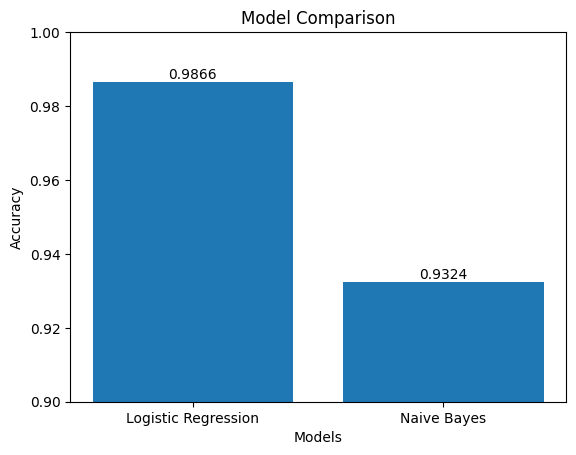

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, y_pred)
nb_acc = accuracy_score(y_test, y_pred_nb)

models = ['Logistic Regression', 'Naive Bayes']
accuracies = [lr_acc, nb_acc]

plt.figure()
bars = plt.bar(models, accuracies)

# show values on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.4f}', ha='center', va='bottom')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.ylim(0.9, 1.0)
plt.show()

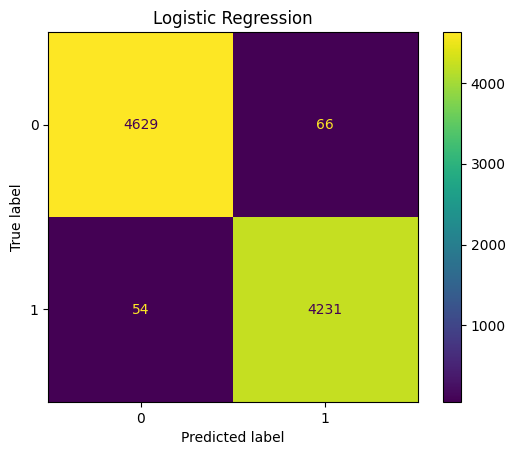

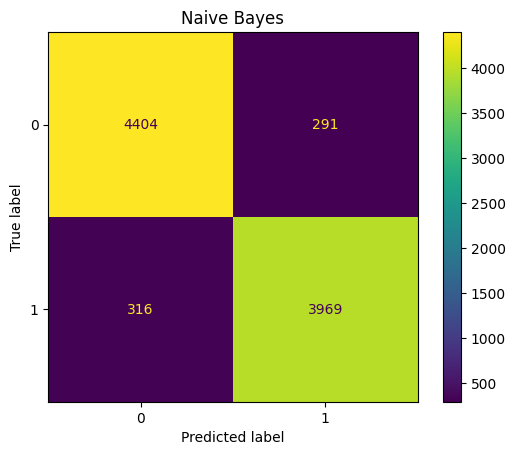

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes")
plt.show()

## Observations

- Logistic Regression performs slightly better than Naive Bayes on this dataset.
- Naive Bayes is used as a baseline model for comparison.
- The model seems to rely more on writing style and common word patterns rather than actual factual correctness.

## Limitations

- The model relies heavily on writing style rather than factual correctness  
- Performs well on structured news articles but struggles with short or context-limited inputs  
- Dataset bias (e.g., source-specific patterns like Reuters) affects generalization  
- The model does not verify real-world truth, only textual patterns